# ガンベル分布：極値統計学の基礎とPythonによる実装

## はじめに

データ分析において「平均的な振る舞い」ではなく「**稀に起こる極端な現象**」に関心がある場合がある。
例えば、
- 100年に一度の大雨の雨量はどれくらいか？
- サーバーへのアクセス集中時の最大負荷はどこまで達するか？
- 金融市場での最大損失額（VaR）は？

こうした「最大値」や「最小値」の統計的性質を扱うのが**極値統計学**である。
本記事では、極値統計学における最も基本的な分布の一つである**ガンベル分布 (Gumbel Distribution)** について解説する。

定義や性質の理論的な説明に加え、Python (SciPy) を用いたパラメータ推定や可視化の実装例、さらに機械学習分野での応用（Gumbel-Max Trick）についても触れる。

## ソースコード

### GitHub
- Jupyter Notebook形式のファイルは[こちら](https://github.com/hiroshi0530/wa-src/blob/master/rec/stats/01/01_nb.ipynb)

### Google Colaboratory
- Google Colaboratory で実行する場合は[こちら](https://colab.research.google.com/github/hiroshi0530/wa-src/blob/master/rec/stats/01/01_nb.ipynb)

## 実行環境
OSはmacOSである。LinuxやUnixのコマンドとはオプションが異なることに注意されたい。

In [17]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [18]:
!python -V

Python 3.14.0


基本的なライブラリをインポートする。

In [19]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import random
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.stats import gumbel_r

seed = 123
random.seed(seed)
np.random.seed(seed)

## 1. 極値統計学とガンベル分布

極値統計学は、観測データの **最大値（または最小値）** のみを取り出して解析する学問領域である。

ある確率分布に従う独立な確率変数 $X_1, X_2, \dots, X_n$ があるとする。
このとき、サンプルサイズ $n$ が十分に大きい場合の最大値
$$
M_n = \max(X_1, X_2, \dots, X_n)
$$
が従う分布は、元の分布の形状に関わらず、特定の3つのタイプの分布（極値分布）のいずれかに収束することが知られている（**フィッシャー・ティペット・グネデンコの定理**）。

その3つのタイプとは以下の通りである。
1. **ガンベル分布 (Type I)**: 指数的な裾を持つ分布（正規分布、指数分布など）の最大値が従う。
2. **フレシェ分布 (Type II)**: べき乗則に従う裾を持つ分布（パレート分布など）の最大値が従う。
3. **ワイブル分布 (Type III)**: 有限の範囲を持つ分布（一様分布など）の最大値が従う。

ガンベル分布は、正規分布やガンマ分布など、多くの一般的な分布から得られるデータの最大値をモデル化するのに適しており、最も広く利用されている。

## 2. ガンベル分布の定義と性質

### 2.1 定義

ガンベル分布は位置パラメータ $\mu \in \mathbb{R}$ と尺度パラメータ $\beta > 0$ を持つ。

**累積分布関数 (CDF)**
$$
F(x; \mu, \beta) = \exp\left(-\exp\left(-\frac{x-\mu}{\beta}\right)\right)
$$

**確率密度関数 (PDF)**
$$
f(x; \mu, \beta) = \frac{1}{\beta} \exp\left(-\frac{x-\mu}{\beta}\right) \exp\left(-\exp\left(-\frac{x-\mu}{\beta}\right)\right)
$$

### 2.2 代表的な統計量

- **平均**: $\mu + \gamma\beta$ （$\gamma \approx 0.5772$ はオイラー定数）
- **分散**: $\displaystyle\frac{\pi^2}{6}\beta^2$
- **中央値**: $\mu - \beta\ln(\ln 2)$
- **最頻値**: $\mu$

分布は右に歪んだ（右の裾が長い）形状をしている。

### 2.3 形状の可視化

Pythonを使って、パラメータを変えたときのガンベル分布の形状を確認してみる。

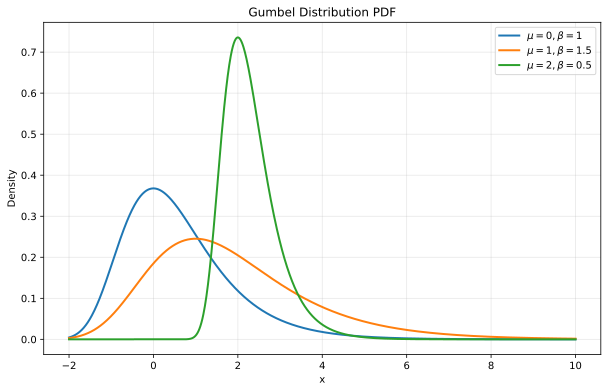

In [20]:
x = np.linspace(-2, 10, 1000)

plt.figure(figsize=(10, 6))

# 異なるパラメータでのプロット
params = [(0, 1), (1, 1.5), (2, 0.5)]
for mu, beta in params:
    y = gumbel_r.pdf(x, loc=mu, scale=beta)
    plt.plot(x, y, label=f'$\\mu={mu}, \\beta={beta}$', lw=2)

plt.title('Gumbel Distribution PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Pythonによる実装とパラメータ推定

実際のデータに対してガンベル分布を当てはめる（フィットさせる）方法を見ていく。
ここでは `scipy.stats.gumbel_r` を使用する（`_r` は right-skewed、つまり通常の最大値ガンベル分布を指す）。

### 3.1 データの生成とフィッティング

まず、既知のパラメータで乱数を生成し、そこからパラメータを推定して元の値を復元できるか確認する。

In [21]:
# 真のパラメータ
mu_true = 5.0
beta_true = 2.0

# データを生成（サンプルサイズ=1000）
data = gumbel_r.rvs(loc=mu_true, scale=beta_true, size=1000, random_state=seed)

# パラメータ推定（最尤推定）
mu_est, beta_est = gumbel_r.fit(data)

print(f"True Parameters:      mu={mu_true}, beta={beta_true}")
print(f"Estimated Parameters: mu={mu_est:.4f}, beta={beta_est:.4f}")

True Parameters:      mu=5.0, beta=2.0
Estimated Parameters: mu=5.0035, beta=1.9955


### 3.2 ヒストグラムと推定分布の比較

データのヒストグラムと、推定されたパラメータに基づく確率密度関数を重ねてプロットする。

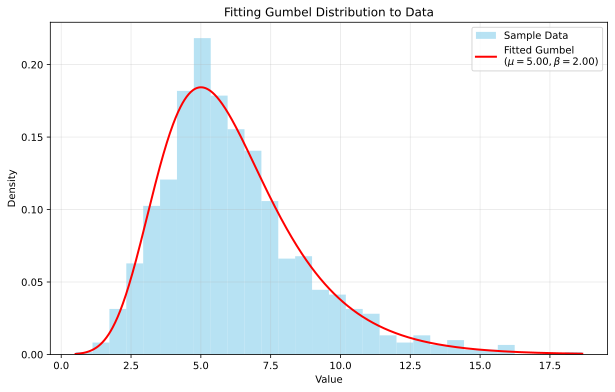

In [22]:
plt.figure(figsize=(10, 6))

# ヒストグラム
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', label='Sample Data')

# 推定された分布
x_range = np.linspace(data.min(), data.max(), 1000)
pdf_est = gumbel_r.pdf(x_range, loc=mu_est, scale=beta_est)
plt.plot(x_range, pdf_est, 'r-', lw=2, label=f'Fitted Gumbel\n($\\mu={mu_est:.2f}, \\beta={beta_est:.2f}$)')

plt.title('Fitting Gumbel Distribution to Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.3 再現期間と再現レベル

極値解析で重要なのが「**再現期間 (Return Period)**」と「**再現レベル (Return Level)**」である。

再現期間 $T$ 年に対応する再現レベル $x_T$（$T$年に一度起こりうる最大値）は以下の式で計算できる。
$$
x_T = \mu - \beta \ln\left(-\ln\left(1 - \frac{1}{T}\right)\right)
$$

例えば、上記のデータ分布において「100年に一度の極値」を計算してみる。

In [23]:
def calculate_return_level(mu, beta, T):
    return mu - beta * np.log(-np.log(1 - 1/T))

T_years = [10, 50, 100]

print("Return Levels:")
for T in T_years:
    level = calculate_return_level(mu_est, beta_est, T)
    print(f"{T} years: {level:.4f}")

Return Levels:
10 years: 9.4940
50 years: 12.7897
100 years: 14.1829


## 4. 機械学習における応用：Gumbel-Max Trick

ガンベル分布は自然現象の解析だけでなく、機械学習の分野でも重要な役割を果たしている。
特に有名なのが **Gumbel-Max Trick** である。

これは、カテゴリカル分布（離散分布）からのサンプリングを効率的に行うためのテクニックである。

クラス $i$ の確率が $p_i \propto \exp(s_i)$ （ソフトマックス形式）で与えられるとき、以下の手順でサンプルを得ることができる。

1. 各クラス $i$ に対して、独立な標準ガンベル分布（$\mu=0, \beta=1$）に従うノイズ $g_i$ を生成する。
2. スコアにノイズを加えた値 $s_i + g_i$ が最大となるインデックスを選ぶ。
   $$
   k = \arg\max_i (s_i + g_i)
   $$

この $k$ は、確率 $p_i$ に従うサンプルとなる。

さらに、この操作を微分可能にするために緩和したものが **Gumbel-Softmax (Concrete Distribution)** であり、VAE（変分オートエンコーダ）などで離散潜在変数を扱う際によく利用される。

In [24]:
# Gumbel-Max Trick の簡単な確認
logits = np.array([1.0, 3.0, 2.0]) # クラスごとのロジット（スコア）
n_samples = 10000

# 標準ガンベルノイズを生成
gumbel_noise = np.random.gumbel(loc=0, scale=1, size=(n_samples, len(logits)))

# argmax を取る
samples = np.argmax(logits + gumbel_noise, axis=1)

# 頻度を集計
counts = np.bincount(samples)
probs_empirical = counts / n_samples

# 理論的なソフトマックス確率
probs_theoretical = np.exp(logits) / np.sum(np.exp(logits))

print("Empirical probabilities:", probs_empirical)
print("Theoretical probabilities:", probs_theoretical)

Empirical probabilities: [0.0903 0.6693 0.2404]
Theoretical probabilities: [0.09003057 0.66524096 0.24472847]


## 結論

本記事では、ガンベル分布について以下の点を解説した。

1. **極値統計学の基礎**: 最大値が従う分布としての位置づけ。
2. **定義と性質**: 特徴的な右に歪んだ形状と、主要な統計量。
3. **Python実装**: `scipy.stats.gumbel_r` を用いたパラメータ推定と可視化。
4. **応用**: 再現期間の計算や、機械学習における Gumbel-Max Trick。

ガンベル分布は、災害対策からAIモデルの最適化まで、意外と幅広い分野で活用されている強力なツールである。

## 参考文献

- 実践ベイズモデリング(豊田秀樹) の第一章に詳細な説明がある。